# Gate noise under inter-run drift  (ZNE vs PEC)

The static composite model assumes **stationary** noise: the channel is identical every run. Real
superconducting devices are **non-stationary** — T1/T2, the biased-Pauli residual and readout
fidelities drift slowly (1/f, TLS, calibration decay) over minutes-to-hours. Since a circuit runs in
ms, the channel is effectively **frozen within a run** and changes **between runs** (the *inter-run*
/ case-B regime; cf. Dasgupta & Humble, arXiv:2308.14756).

This notebook studies **gate-noise mitigation** (ZNE vs PEC) under drift on the **gate-only**
composite (`thermal ∘ mixed-unitary`, no readout) — so P(success) reaches ~1.0 with **no readout
floor** to confound the reading. This mirrors the static split: `Composite_noise_DZNE` (gate-only)
vs `Composite_readout_TREX` (full stack). The **readout channel under drift + TREX** is its sibling,
`Composite_drift_TREX.ipynb`. Machinery: `qem/drift.py` + the `drift_models=` argument of
`run_benchmark`.

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

# Make the qem/ package importable regardless of the kernel working directory.
import sys
from pathlib import Path
for _cand in (Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents):
    if (_cand / "qem" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break
from qem import *
from qem.noise_models import T1_S, T2_S, EPS_MU_1Q, EPS_MU_2Q  # nominal magnitudes

warnings.filterwarnings("ignore")
print("qem loaded. Gate-only spec:", SPEC_COMPOSITE.name)
print("Nominal theta:", NOMINAL_PARAMS)

qem loaded. Gate-only spec: Composite
Nominal theta: NoiseParams(t1=0.0001, t2=8e-05, eps_1q=0.001, eps_2q=0.005, readout=ReadoutSpec(name='ReadoutRealistic', p0=(0.01, 0.013), p1=(0.025, 0.03)))


## 2. The drift model — Ornstein-Uhlenbeck, one clock per mechanism

Drift is **not a new channel**, just a time-modulation of the composite's parameters. We keep **one**
composite model per run and drive its parameters with **independent Ornstein-Uhlenbeck (OU)**
trajectories — one per physically-distinct mechanism ({T1}, {T2}, {gate ε}, {readout}):

$$x_{t+1} = \mu + (x_t-\mu)\,e^{-1/\tau} + \sigma_{\text{stat}}\sqrt{1-e^{-2/\tau}}\;\mathcal N(0,1)$$

OU is **mean-reverting** (parameters fluctuate around their calibrated value $\mu$ without wandering
off) with a **stationary** spread $\sigma_{\text{stat}}=\sigma_{\text{rel}}\,|\mu|$ and correlation
time $\tau$ (in *runs* — "how fast calibration goes stale"). `gate_scale` / `readout_scale` are
multipliers, so the structural ratios (5× 2q/1q, readout asymmetry, $\eta$) stay fixed. The
trajectory is **seeded** (replay identical drift for fair comparisons); the shot RNG stays free (the
seedless anti-bias PEC fix).

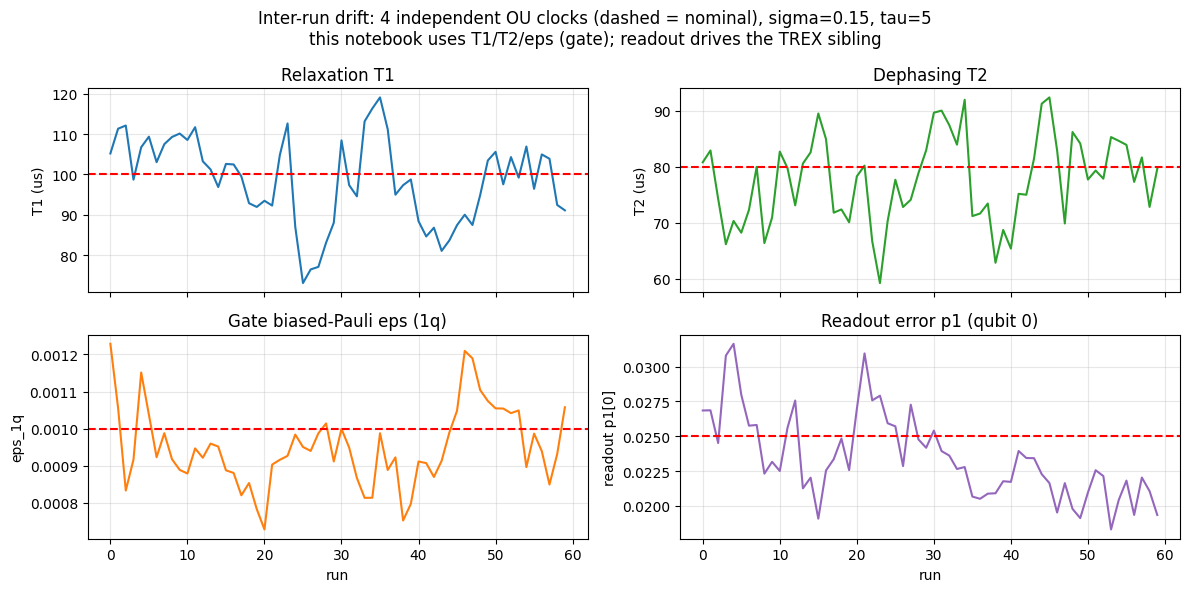

In [2]:
def drift_config(sigma, tau=5.0):
    "One OU per mechanism, all at relative strength `sigma` (T2 a touch more volatile)."
    return DriftConfig(
        t1=OUParams(mu=T1_S, tau=tau, sigma_rel=sigma, lo=1e-9),
        t2=OUParams(mu=T2_S, tau=tau, sigma_rel=1.2 * sigma, lo=1e-9),
        gate_scale=OUParams(mu=1.0, tau=tau, sigma_rel=sigma, lo=0.0),
        readout_scale=OUParams(mu=1.0, tau=tau, sigma_rel=sigma, lo=0.0),
    )

def make_drift_models(n_runs, sigma, tau=5.0, seed=0):
    # GATE-ONLY models (no readout) -> no readout floor; the drifting readout in theta drives the
    # sibling TREX notebook instead.
    return [build_drift_gate_model(p)
            for p in drift_params(n_runs, seed=seed, config=drift_config(sigma, tau))]

# Visualise one trajectory (sigma=0.15, tau=5) over 60 runs.
traj = drift_params(60, seed=1, config=drift_config(0.15))
runs = np.arange(len(traj))
fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
ax[0, 0].plot(runs, [p.t1 * 1e6 for p in traj]); ax[0, 0].axhline(T1_S * 1e6, ls="--", c="r")
ax[0, 0].set_ylabel("T1 (us)"); ax[0, 0].set_title("Relaxation T1")
ax[0, 1].plot(runs, [p.t2 * 1e6 for p in traj], c="tab:green")
ax[0, 1].axhline(T2_S * 1e6, ls="--", c="r")
ax[0, 1].set_ylabel("T2 (us)"); ax[0, 1].set_title("Dephasing T2")
ax[1, 0].plot(runs, [p.eps_1q for p in traj], c="tab:orange")
ax[1, 0].axhline(EPS_MU_1Q, ls="--", c="r")
ax[1, 0].set_ylabel("eps_1q"); ax[1, 0].set_xlabel("run"); ax[1, 0].set_title("Gate biased-Pauli eps (1q)")
ax[1, 1].plot(runs, [p.readout.p1[0] for p in traj], c="tab:purple")
ax[1, 1].axhline(NOMINAL_PARAMS.readout.p1[0], ls="--", c="r")
ax[1, 1].set_ylabel("readout p1[0]"); ax[1, 1].set_xlabel("run")
ax[1, 1].set_title("Readout error p1 (qubit 0)")
for a in ax.ravel():
    a.grid(alpha=0.3)
fig.suptitle("Inter-run drift: 4 independent OU clocks (dashed = nominal), sigma=0.15, tau=5\n"
             "this notebook uses T1/T2/eps (gate); readout drives the TREX sibling")
plt.tight_layout(); plt.show()

## 3. Why static PEC breaks: a stale-calibration snapshot

The cleanest way to see the failure is a **fixed** "stale calibration" channel: gate noise $2\times$,
coherence $0.6\times$. PEC keeps building its quasi-probability reps from the **nominal** parameters —
they no longer invert the actual channel, so PEC (unbiased at nominal) becomes **biased**, while the
model-free ZNE fit (`Exp`) — which only assumes monotone amplification — barely moves.

Running nominal-channel benchmark ...
Running stale-calibration benchmark ...

method     |  bias nom bias stale |   MSE nom MSE stale
Noisy      |   -0.1428    -0.2410 |   0.02127   0.06010
Exp        |    0.0030     0.0090 |   0.00071   0.00139
AdaExp     |    0.0052    -0.0060 |   0.00053   0.00172
PEC        |   -0.0001    -0.1084 |   0.00404   0.01640


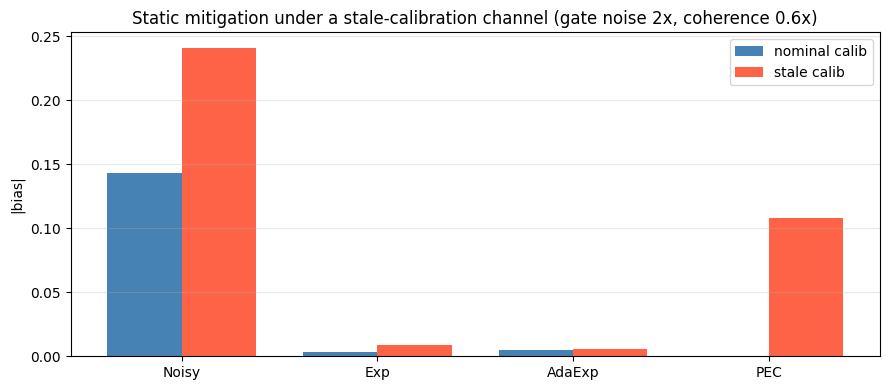

In [4]:
N_DRIFT = 16      # seeds per benchmark (modest for runtime; scale up for smoother stats)
BUDGET = 12_000   # shots / circuit / method
seeds = list(range(N_DRIFT))
NAME = SPEC_COMPOSITE.name

def col(df, m, c):
    return float(df.loc[(NAME, m), c])

# Fixed "stale calibration": gate noise 2x, coherence 0.6x (readout unused -> gate-only model).
bad = NoiseParams(t1=T1_S * 0.6, t2=T2_S * 0.6, eps_1q=EPS_MU_1Q * 2, eps_2q=EPS_MU_2Q * 2,
                  readout=NOMINAL_PARAMS.readout)

print("Running nominal-channel benchmark ...")
df_nom, _, _ = run_benchmark(SPEC_COMPOSITE, seeds=seeds, shot_budget=BUDGET, verbose=False)
print("Running stale-calibration benchmark ...")
df_stale, _, _ = run_benchmark(SPEC_COMPOSITE, seeds=seeds, shot_budget=BUDGET,
                               drift_models=[build_drift_gate_model(bad) for _ in seeds],
                               verbose=False)

methods = ["Noisy", "Exp", "AdaExp", "PEC"]
print(f"\n{'method':10s} | {'bias nom':>9s} {'bias stale':>10s} | {'MSE nom':>9s} {'MSE stale':>9s}")
for m in methods:
    print(f"{m:10s} | {col(df_nom, m, 'bias'):>9.4f} {col(df_stale, m, 'bias'):>10.4f} | "
          f"{col(df_nom, m, 'mse'):>9.5f} {col(df_stale, m, 'mse'):>9.5f}")

x = np.arange(len(methods)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, [abs(col(df_nom, m, "bias")) for m in methods], w,
       label="nominal calib", color="steelblue")
ax.bar(x + w / 2, [abs(col(df_stale, m, "bias")) for m in methods], w,
       label="stale calib", color="tomato")
ax.set_xticks(x); ax.set_xticklabels(methods); ax.set_ylabel("|bias|")
ax.set_title("Static mitigation under a stale-calibration channel (gate noise 2x, coherence 0.6x)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 4. Degradation vs drift strength

Now the **gate** channel drifts (T1/T2/eps) at increasing relative strength $\sigma$, using the
**same** random realisation scaled up ($\sigma=0$ = the static baseline). We track every method's bias
and MSE on a **fine grid** ($\sigma$ up to 0.45); the shaded band marks the **physically realistic**
regime ($\sigma\lesssim0.25$; real devices drift $\lesssim25\%$, cf. arXiv:2404.13269), beyond which
is a deliberate stress test.

> **Runtime:** this is the heavy cell — the full benchmark (incl. PEC) runs once per $\sigma$
> (10 points × `N_DRIFT` seeds). Dial `N_DRIFT` / `BUDGET` (§3) down for a quick look.

sigma=0.00 done  Noisy -0.140  Poly2 +0.001  Exp +0.008  AdaExp +0.012  PEC +0.012
sigma=0.05 done  Noisy -0.146  Poly2 +0.000  Exp +0.006  AdaExp +0.006  PEC +0.003
sigma=0.10 done  Noisy -0.149  Poly2 -0.007  Exp +0.005  AdaExp +0.005  PEC +0.006
sigma=0.15 done  Noisy -0.154  Poly2 -0.005  Exp +0.007  AdaExp +0.003  PEC +0.008
sigma=0.20 done  Noisy -0.157  Poly2 -0.014  Exp +0.018  AdaExp -0.001  PEC -0.052
sigma=0.25 done  Noisy -0.161  Poly2 -0.017  Exp +0.009  AdaExp +0.009  PEC -0.053
sigma=0.30 done  Noisy -0.167  Poly2 -0.010  Exp +0.010  AdaExp +0.008  PEC -0.028
sigma=0.35 done  Noisy -0.172  Poly2 -0.015  Exp +0.020  AdaExp -0.010  PEC -0.015
sigma=0.40 done  Noisy -0.178  Poly2 -0.021  Exp +0.000  AdaExp -0.001  PEC -0.064
sigma=0.45 done  Noisy -0.196  Poly2 -0.030  Exp +0.004  AdaExp -0.008  PEC -0.050

MSE vs sigma (all methods):
         Noisy    Poly2      Exp   AdaExp      PEC
sigma                                             
0.00   0.02041  0.00068  0.00089  0.000

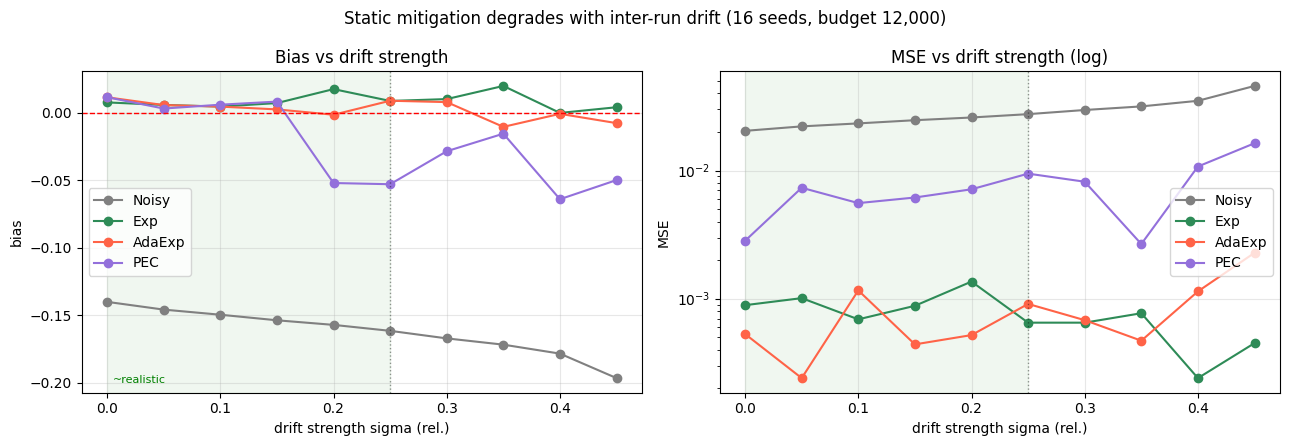

In [5]:
SIGMAS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
SIGMA_REP = 0.25  # representative "strong but ~realistic" drift, reused for the §5 distribution plots
METHODS = ["Noisy", "Poly2", "Exp", "AdaExp", "PEC"]

sweep = {m: {"bias": [], "mse": []} for m in METHODS}
df_rep = raw_rep = None
rows = []
for sig in SIGMAS:
    models = None if sig == 0.0 else make_drift_models(N_DRIFT, sig, seed=0)  # sigma=0 -> static
    df, res, _ = run_benchmark(SPEC_COMPOSITE, seeds=seeds, shot_budget=BUDGET,
                               drift_models=models, verbose=False)
    for m in METHODS:
        sweep[m]["bias"].append(col(df, m, "bias"))
        sweep[m]["mse"].append(col(df, m, "mse"))
    rows.append({"sigma": sig, **{m: round(col(df, m, "mse"), 5) for m in METHODS}})
    if abs(sig - SIGMA_REP) < 1e-9:
        df_rep, raw_rep = df, res
    print(f"sigma={sig:.2f} done  " + "  ".join(f"{m} {col(df, m, 'bias'):+.3f}" for m in METHODS))

print("\nMSE vs sigma (all methods):")
print(pd.DataFrame(rows).set_index("sigma").to_string())

plot_m = ["Noisy", "Exp", "AdaExp", "PEC"]
cmap = {"Noisy": "gray", "Poly2": "darkorange", "Exp": "seagreen",
        "AdaExp": "tomato", "PEC": "mediumpurple"}
fig, (axb, axm) = plt.subplots(1, 2, figsize=(13, 4.5))
for m in plot_m:
    axb.plot(SIGMAS, sweep[m]["bias"], "o-", c=cmap[m], label=m)
    axm.plot(SIGMAS, sweep[m]["mse"], "o-", c=cmap[m], label=m)
for a in (axb, axm):
    a.axvspan(0, 0.25, color="green", alpha=0.06)          # ~realistic drift (<~25%)
    a.axvline(SIGMA_REP, ls=":", c="k", lw=1, alpha=0.4)
    a.set_xlabel("drift strength sigma (rel.)"); a.grid(alpha=0.3); a.legend()
axb.axhline(0, ls="--", c="r", lw=1); axb.set_ylabel("bias"); axb.set_title("Bias vs drift strength")
axm.set_yscale("log"); axm.set_ylabel("MSE"); axm.set_title("MSE vs drift strength (log)")
axb.text(0.005, 0.03, "~realistic", transform=axb.get_xaxis_transform(), fontsize=8, color="green")
fig.suptitle(f"Static mitigation degrades with inter-run drift ({N_DRIFT} seeds, budget {BUDGET:,})")
plt.tight_layout(); plt.show()

## 5. P(success) distribution at a representative drift

For consistency with the other benchmark notebooks (`Composite_noise_DZNE.ipynb`), the per-method
**P(success) distribution** and its **bias²/variance decomposition** at a fixed, still-realistic drift
($\sigma=0.25$, reused from the §4 sweep). The aggregate metrics hide the *shape*: under drift PEC's
error shows up as **variance / heavy tails** (its sign-problem outliers, amplified by the channel
mismatch), which the boxplot's outliers expose — while the exponential ZNE fits stay tight near 1.0.

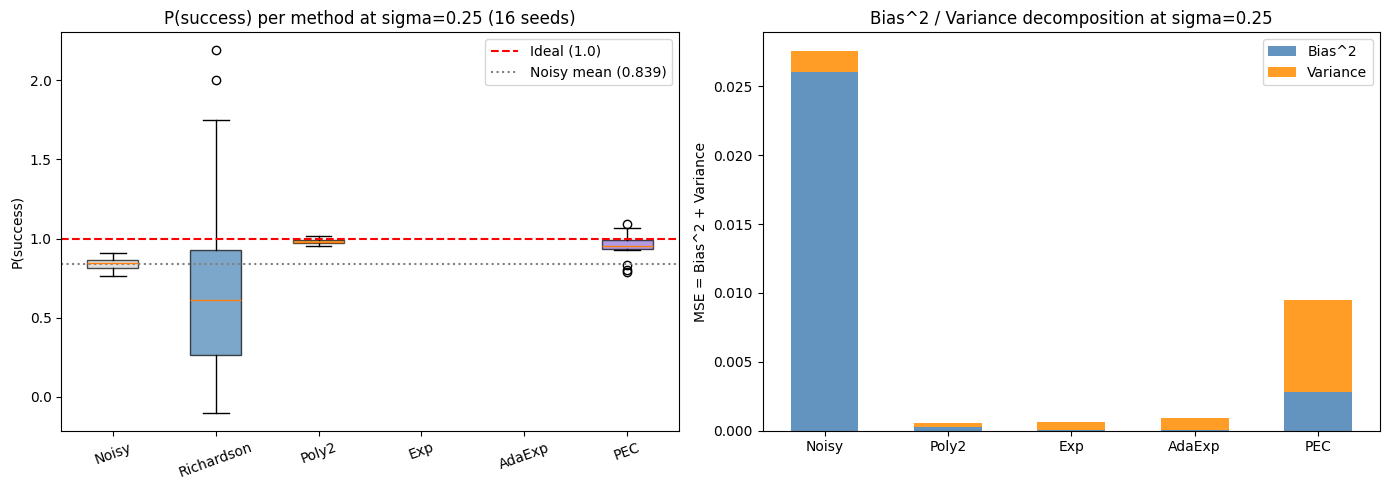

In [6]:
labels = ["Noisy", "Richardson", "Poly2", "Exp", "AdaExp", "PEC"]
colors = ["lightgray", "steelblue", "darkorange", "seagreen", "tomato", "mediumpurple"]
data = [np.asarray(raw_rep[k], dtype=float) for k in labels]
noisy_mean = np.nanmean(data[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
bp = ax1.boxplot(data, labels=labels, patch_artist=True, showfliers=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax1.axhline(IDEAL, color="red", ls="--", lw=1.5, label=f"Ideal ({IDEAL})")
ax1.axhline(noisy_mean, color="gray", ls=":", lw=1.5, label=f"Noisy mean ({noisy_mean:.3f})")
ax1.set_ylabel("P(success)"); ax1.tick_params(axis="x", rotation=20)
ax1.set_title(f"P(success) per method at sigma={SIGMA_REP} ({N_DRIFT} seeds)"); ax1.legend()

mm = ["Noisy", "Poly2", "Exp", "AdaExp", "PEC"]
bias2 = [col(df_rep, m, "bias") ** 2 for m in mm]
var = [col(df_rep, m, "variance") for m in mm]
xx = np.arange(len(mm))
ax2.bar(xx, bias2, 0.55, label="Bias^2", color="steelblue", alpha=0.85)
ax2.bar(xx, var, 0.55, bottom=bias2, label="Variance", color="darkorange", alpha=0.85)
ax2.set_xticks(xx); ax2.set_xticklabels(mm); ax2.set_ylabel("MSE = Bias^2 + Variance")
ax2.set_title(f"Bias^2 / Variance decomposition at sigma={SIGMA_REP}"); ax2.legend()
plt.tight_layout(); plt.show()

### Summary

Under **stationary** gate noise, static PEC inverts the exact channel and is unbiased. Under
**inter-run drift** its quasi-probability reps — built from nominal parameters — no longer match the
drifted channel:

- **§3 (fixed stale channel)** isolates the mechanism: PEC's variance is unchanged but its **bias
  jumps** (nominal reps under-correct), while model-free `Exp` ZNE barely moves.
- **§4 (strength sweep)** shows, across the whole range, the **exponential/adaptive ZNE fits stay
  robust** (an apparent breakdown seen with a coarse 12-seed grid was a small-sample artifact), while
  PEC degrades — clearly for $\sigma\gtrsim0.3$, crossing above ZNE.
- **§5** exposes the *shape*: under symmetric drift PEC's error is **variance / heavy tails**, not
  bias (a persistent stale calibration, §3, hits it as bias instead) — two distinct failure modes.

This is the concrete, in-framework evidence that **static characterisation is the bottleneck** under
non-stationary noise. The **same story on the readout channel** — TREX's calibration going stale — is
in the sibling `Composite_drift_TREX.ipynb`. Both motivate the next step: **re-learning** the channel
per run (noise-model learning) and amplifying the *learned* noise (**PEA**) to restore accuracy
(targets: the 4.5× of Dasgupta & Humble, arXiv:2308.14756; the +42% of arXiv:2404.13269).